In [4]:
import tensorflow as tf

tf.keras.utils.set_random_seed(39)

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) =\
     keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.23, random_state=39)

In [5]:
print("훈련데이터 :")
print(train_scaled.shape, train_target.shape)
print("테스트데이터 :")
print(test_input.shape, test_target.shape)
print("검증데이터 :")
print(val_scaled.shape, val_target.shape)

훈련데이터 :
(46200, 28, 28) (46200,)
테스트데이터 :
(10000, 28, 28) (10000,)
검증데이터 :
(13800, 28, 28) (13800,)


In [7]:
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))
    model.add(keras.layers.Dense(500, activation='relu'))

    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(100, activation='softmax'))
    return model

In [23]:
model = model_fn()
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_13 (Flatten)        (None, 784)               0         
                                                                 
 dense_26 (Dense)            (None, 500)               392500    
                                                                 
 dense_27 (Dense)            (None, 100)               50100     
                                                                 
Total params: 442,600
Trainable params: 442,600
Non-trainable params: 0
_________________________________________________________________


In [24]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [25]:
history = model.fit(train_scaled, train_target, epochs=10, verbose=1)

Epoch 1/10
1444/1444 [==============================] - 138s 3ms/step - loss: 0.5300 - accuracy: 0.8133
Epoch 2/10
1444/1444 [==============================] - 5s 3ms/step - loss: 0.3873 - accuracy: 0.8619
Epoch 3/10
1444/1444 [==============================] - 5s 3ms/step - loss: 0.3601 - accuracy: 0.8735
Epoch 4/10
1444/1444 [==============================] - 5s 3ms/step - loss: 0.3446 - accuracy: 0.8811
Epoch 5/10
1444/1444 [==============================] - 5s 3ms/step - loss: 0.3288 - accuracy: 0.8871
Epoch 6/10
1444/1444 [==============================] - 5s 3ms/step - loss: 0.3193 - accuracy: 0.8916
Epoch 7/10
1444/1444 [==============================] - 5s 4ms/step - loss: 0.3110 - accuracy: 0.8941
Epoch 8/10
1444/1444 [==============================] - 5s 3ms/step - loss: 0.3047 - accuracy: 0.9002
Epoch 9/10
1444/1444 [==============================] - 5s 4ms/step - loss: 0.3001 - accuracy: 0.9020
Epoch 10/10
1444/1444 [==============================] - 6s 4ms/step - loss: 0.2

In [26]:
print(history)

In [27]:
print(history.history.keys())

dict_keys(['loss', 'accuracy'])


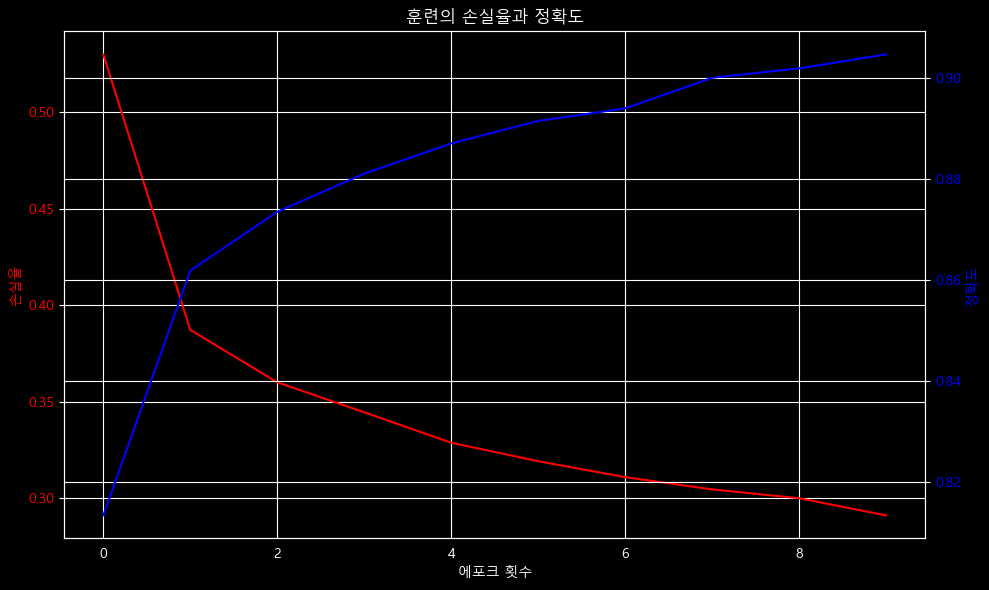

In [34]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('에포크 횟수')
ax1.set_ylabel('손실율', color='red')
ax1.plot(history.history['loss'], color='red', label='Loss')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.set_ylabel('정확도', color='blue')
ax2.plot(history.history['accuracy'], color='blue', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('훈련의 손실율과 정확도')
fig.tight_layout()
plt.show()

In [35]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1)

Epoch 1/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.5296 - accuracy: 0.8143
Epoch 2/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3881 - accuracy: 0.8621
Epoch 3/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3589 - accuracy: 0.8737
Epoch 4/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3446 - accuracy: 0.8815
Epoch 5/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3280 - accuracy: 0.8867
Epoch 6/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3186 - accuracy: 0.8916
Epoch 7/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3122 - accuracy: 0.8946
Epoch 8/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3030 - accuracy: 0.8993
Epoch 9/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.2998 - accuracy: 0.9014
Epoch 10/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.292

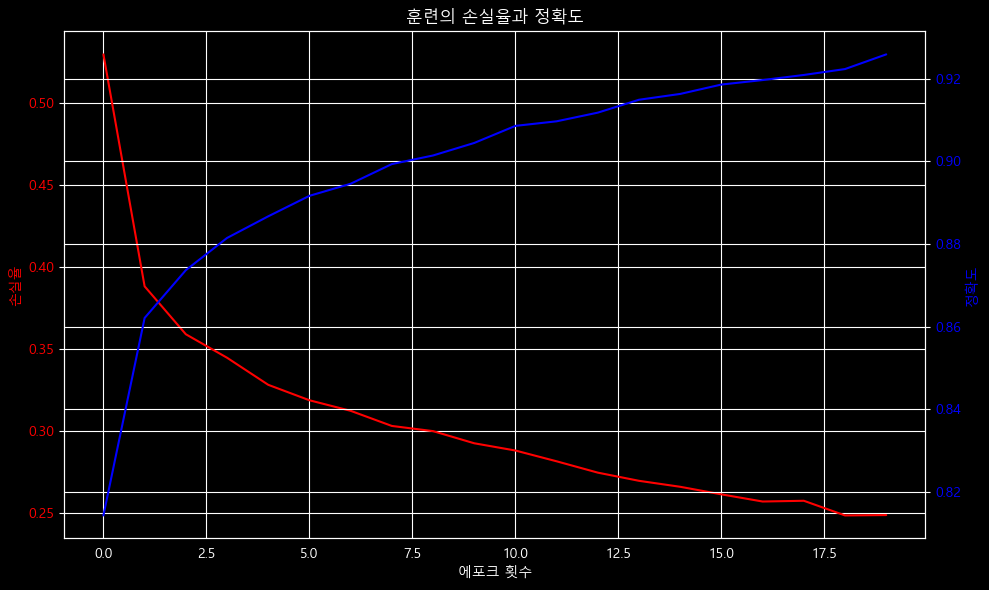

In [36]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('에포크 횟수')
ax1.set_ylabel('손실율', color='red')
ax1.plot(history.history['loss'], color='red', label='Loss')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.set_ylabel('정확도', color='blue')
ax2.plot(history.history['accuracy'], color='blue', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('훈련의 손실율과 정확도')
fig.tight_layout()
plt.show()

In [37]:
model = model_fn()
model.summary()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_15 (Flatten)        (None, 784)               0         
                                                                 
 dense_30 (Dense)            (None, 500)               392500    
                                                                 
 dense_31 (Dense)            (None, 100)               50100     
                                                                 
Total params: 442,600
Trainable params: 442,600
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
1444/1444 [==============================] - 4s 2ms/step - loss: 0.5288 - accuracy: 0.8119 - val_loss: 0.4129 - val_accuracy: 0.8563
Epoch 2/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3887 - accuracy: 0.8617 - val_loss: 0.3784 - val_accuracy: 0.8683
Epoch 3/20
1444/1444 [=

In [38]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


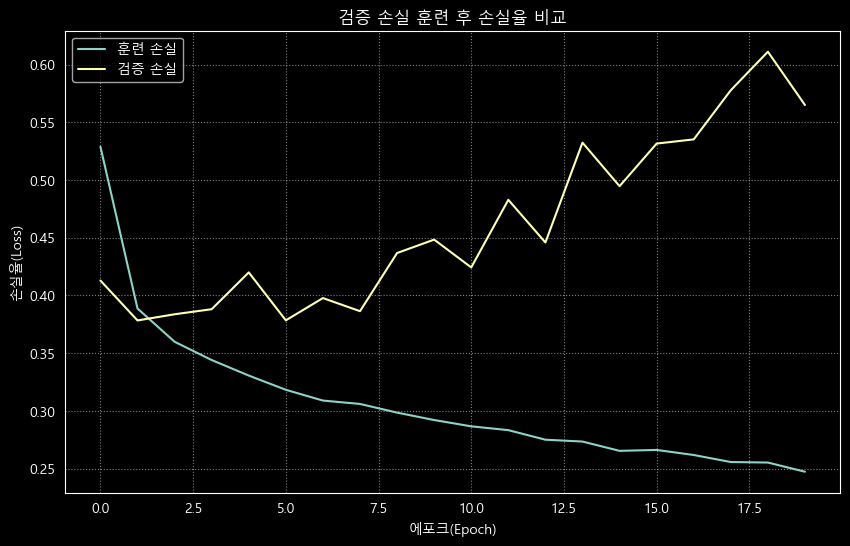

In [40]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='훈련 손실')
plt.plot(history.history['val_loss'], label='검증 손실')

plt.title('검증 손실 훈련 후 손실율 비교')
plt.xlabel('에포크(Epoch)')
plt.ylabel('손실율(Loss)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

Epoch 1/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.5180 - accuracy: 0.8189 - val_loss: 0.4133 - val_accuracy: 0.8480
Epoch 2/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3776 - accuracy: 0.8635 - val_loss: 0.3662 - val_accuracy: 0.8653
Epoch 3/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3364 - accuracy: 0.8763 - val_loss: 0.3645 - val_accuracy: 0.8656
Epoch 4/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3116 - accuracy: 0.8854 - val_loss: 0.3458 - val_accuracy: 0.8750
Epoch 5/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.2913 - accuracy: 0.8919 - val_loss: 0.3640 - val_accuracy: 0.8694
Epoch 6/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.2760 - accuracy: 0.8964 - val_loss: 0.3266 - val_accuracy: 0.8842
Epoch 7/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.2604 - accuracy: 0.9029 - val_loss: 0.3273 - val_accuracy:

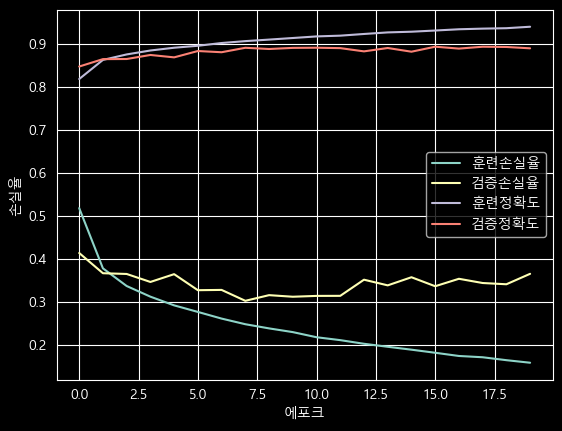

In [43]:
model = model_fn()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('에포크')
plt.ylabel('손실율')
plt.legend(['훈련손실율', '검증손실율','훈련정확도', '검증정확도'])
plt.show()

In [44]:
model = model_fn(keras.layers.Dropout(0.25))
model.summary()

Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_19 (Flatten)        (None, 784)               0         
                                                                 
 dense_38 (Dense)            (None, 500)               392500    
                                                                 
 dropout (Dropout)           (None, 500)               0         
                                                                 
 dense_39 (Dense)            (None, 100)               50100     
                                                                 
Total params: 442,600
Trainable params: 442,600
Non-trainable params: 0
_________________________________________________________________


Epoch 1/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.5490 - accuracy: 0.8077 - val_loss: 0.4164 - val_accuracy: 0.8482
Epoch 2/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.4077 - accuracy: 0.8516 - val_loss: 0.3876 - val_accuracy: 0.8573
Epoch 3/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3708 - accuracy: 0.8630 - val_loss: 0.3601 - val_accuracy: 0.8662
Epoch 4/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3490 - accuracy: 0.8731 - val_loss: 0.3485 - val_accuracy: 0.8724
Epoch 5/20
1444/1444 [==============================] - 4s 2ms/step - loss: 0.3306 - accuracy: 0.8775 - val_loss: 0.3421 - val_accuracy: 0.8733
Epoch 6/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3163 - accuracy: 0.8824 - val_loss: 0.3534 - val_accuracy: 0.8713
Epoch 7/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3081 - accuracy: 0.8854 - val_loss: 0.3271 - val_accuracy:

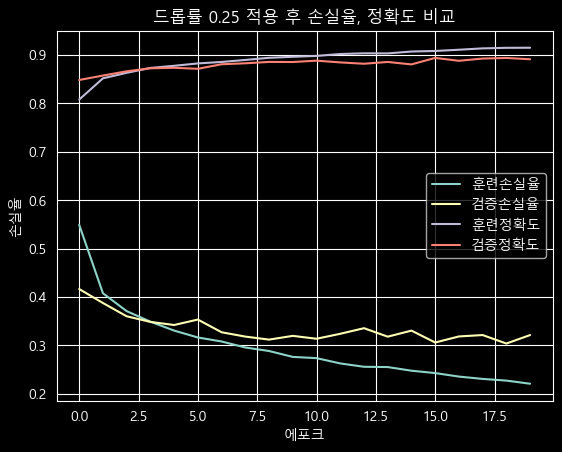

In [45]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))

plt.title('드롭률 0.25 적용 후 손실율, 정확도 비교')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('에포크')
plt.ylabel('손실율')
plt.legend(['훈련손실율', '검증손실율','훈련정확도', '검증정확도'])
plt.show()

In [49]:
model = model_fn(keras.layers.Dropout(0.25))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

model.save('AI기반 예측 및 분석 시험.keras')
model.save_weights('AI기반 예측 및 분석 시험.h5')

In [51]:
!dir AI기반*

 Volume in drive C has no label.
 Volume Serial Number is F651-45CF

 Directory of C:\Users\수빈36\Documents\pythonStudy26

2026-03-06  오후 03:12         1,785,768 AI기반 예측 및 분석 시험.h5
2026-03-06  오후 03:12           278,790 AI기반 예측 및 분석 시험.ipynb
2026-03-06  오후 03:12         5,338,184 AI기반 예측 및 분석 시험.keras
               3 File(s)      7,402,742 bytes
               0 Dir(s)  1,560,919,232,512 bytes free


In [52]:
model = model_fn(keras.layers.Dropout(0.29))
model.load_weights('AI기반 예측 및 분석 시험.h5')
model.summary()

Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_24 (Flatten)        (None, 784)               0         
                                                                 
 dense_48 (Dense)            (None, 500)               392500    
                                                                 
 dropout_5 (Dropout)         (None, 500)               0         
                                                                 
 dense_49 (Dense)            (None, 100)               50100     
                                                                 
Total params: 442,600
Trainable params: 442,600
Non-trainable params: 0
_________________________________________________________________


In [53]:
import numpy as np
val_labels = np.argmax(model.predict(val_scaled), axis=-1)
print(np.mean(val_labels == val_target))

432/432 [==============================] - 0s 781us/step
0.888695652173913


In [54]:
model = keras.models.load_model('AI기반 예측 및 분석 시험.keras')
model.evaluate(val_scaled, val_target)

432/432 [==============================] - 1s 1ms/step - loss: 0.3411 - accuracy: 0.8887


[0.3411363363265991, 0.8886956572532654]

In [55]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)

model.fit(train_scaled, train_target, epochs=20, verbose=1,
          validation_data=(val_scaled, val_target),
          callbacks=[checkpoint_cb])

Epoch 1/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.5548 - accuracy: 0.8041 - val_loss: 0.4244 - val_accuracy: 0.8454
Epoch 2/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.4133 - accuracy: 0.8480 - val_loss: 0.4080 - val_accuracy: 0.8467
Epoch 3/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3778 - accuracy: 0.8614 - val_loss: 0.3685 - val_accuracy: 0.8636
Epoch 4/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3568 - accuracy: 0.8708 - val_loss: 0.3454 - val_accuracy: 0.8741
Epoch 5/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3408 - accuracy: 0.8740 - val_loss: 0.3487 - val_accuracy: 0.8691
Epoch 6/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3243 - accuracy: 0.8798 - val_loss: 0.3399 - val_accuracy: 0.8776
Epoch 7/20
1444/1444 [==============================] - 3s 2ms/step - loss: 0.3173 - accuracy: 0.8824 - val_loss: 0.3293 - val_accuracy:

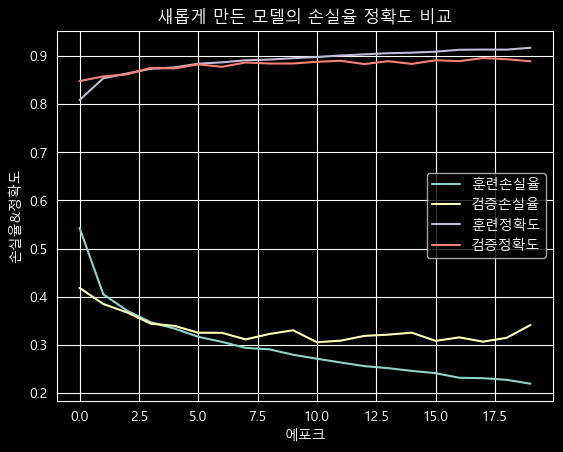

432/432 [==============================] - 1s 1ms/step - loss: 0.3302 - accuracy: 0.8899


[0.33016449213027954, 0.8898550868034363]

In [59]:
plt.title('새롭게 만든 모델의 손실율 정확도 비교')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('에포크')
plt.ylabel('손실율&정확도')
plt.legend(['훈련손실율', '검증손실율','훈련정확도', '검증정확도'])
plt.show()
model.evaluate(val_scaled, val_target)